**Dataset:**
personality type data (Lab 2 - Personality Profile Type.csv)

**Objective:**
classify Personality type as one of the following **using RNNs**. <br>
['INFJ', 'ENTP', 'INTP', 'INTJ', 'ENTJ', 'ENFJ', 'INFP', 'ENFP',
       'ISFP', 'ISTP', 'ISFJ', 'ISTJ', 'ESTP', 'ESFP', 'ESTJ', 'ESFJ']

**Evaluation metric:**
Precision

### Import used libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout , SimpleRNN ,Bidirectional ,BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score ,precision_score
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 500)

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load Dataset

In [25]:
df = pd.read_csv("/content/drive/MyDrive/Lab 3 - Personality Profile Type.csv")
df.head(10)

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1rooo1_500.jpg|||enfp and intj moments https://www.youtube.com/watch?v=iz7lE1g4XM4 sportscenter not top ten plays https://www.youtube.com/watch?v=uCdfze1etec pranks|||What has been the most life-changing experience in your life?|||http://www.youtube.com/watch?v=vXZeYwwRDw8 http://www.youtube.com/watch?v=u8ejam5DP3E On repeat for most of today.|||May the PerC Experience immerse you.|||The last ...
1,ENTP,'I'm finding the lack of me in these posts very alarming.|||Sex can be boring if it's in the same position often. For example me and my girlfriend are currently in an environment where we have to creatively use cowgirl and missionary. There isn't enough...|||Giving new meaning to 'Game' theory.|||Hello *ENTP Grin* That's all it takes. Than we converse and they do most of the flirting while I acknowledge their presence and return their words with smooth wordplay and more cheeky grins.|||This...
2,INTP,"'Good one _____ https://www.youtube.com/watch?v=fHiGbolFFGw|||Of course, to which I say I know; that's my blessing and my curse.|||Does being absolutely positive that you and your best friend could be an amazing couple count? If so, than yes. Or it's more I could be madly in love in case I reconciled my feelings (which at...|||No, I didn't; thank you for a link!|||So-called Ti-Si loop (and it can stem from any current topic/obsession) can be deadly. It's like when you're stuck in your o..."
3,INTJ,"'Dear INTP, I enjoyed our conversation the other day. Esoteric gabbing about the nature of the universe and the idea that every rule and social code being arbitrary constructs created...|||Dear ENTJ sub, Long time no see. Sincerely, Alpha|||None of them. All other types hurt in deep existential ways that I want no part of.|||Probably a sliding scale that depends on individual preferences, like everything in humanity.|||Draco Malfoy also. I'd say he's either 358 or 368.|||I'm either 358..."
4,ENTJ,'You're fired.|||That's another silly misconception. That approaching is logically is going to be the key to unlocking whatever it is you think you are entitled to. Nobody wants to be approached with BS...|||But guys... he REALLY wants to go on a super-duper-long-ass vacation. C'mon guys. His boss just doesn't listen or get it. He even approached him logically and everything.|||Never mind. Just go on permanent vacation.|||Two months? I wouldn't be crazy about the idea. If you are really hi...
5,INTJ,"'18/37 @.@|||Science is not perfect. No scientist claims that it is, or that scientific information will not be revised as we discover new things. Rational thinking has been very useful to our society....|||INFP- Edgar Allen Poe was an INFP and he's in your siggy.|||People see the obvious Fi and are quick to put her as INFP. I agree that she has no Ne. I see her as an ISFP. Compare her to Haku (definite INFP). She is flat through most of Naruto.. but I don't...|||Lets get this party star..."
6,INFJ,"'No, I can't draw on my own nails (haha). Those were done by professionals on my nails. And yes, those are all gel. You mean those you posted were done by yourself on your own nails? Awesome!|||Probably the Electronic Screen Syndrome. With the advent of technology and social media, we all suffer from overstimulation on a daily basis. I'm guilty as well. In the past, I can be happy just...|||I love nail arts too! These are some of mine: 718282 718290 718298 718306 718314|||This is the first..."
7,INTJ,"'I tend to build up a collection of things on my desktop that i use frequently and then move them into a folder called 'Everything' from there it get sorted into type and sub type|||i ike to collect odd objects, even at work...a lot of people would call it junk but i like to collect it. Old unused software? ill take that off your hands :) i have a bunch of old adobe...|||i think its quite normal, i tend to only see my friends in real life every c

### Data splitting

In [26]:
X = df['posts']
y = df['type']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5,random_state=42)

In [28]:
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (6940,)
X_val shape: (867,)
X_test shape: (868,)


### EDA on training data

- check NaNs

In [29]:
df['posts'].isna().sum()

np.int64(0)

- check duplicates

In [30]:
df['posts'].duplicated().sum()

np.int64(0)

- show a representative sample of data texts to find out required preprocessing steps

In [31]:
df['posts'].sample(10)

,posts
7967,"'I love your writing style|||I dont have a cupboard, I have a drawer where everything is thrown in and made into a huge mess. I have a general idea whats in there and I am trying to sort it all out|||... I suppose the challenge is following through :tongue: Yup I would agree with this. Do you guys tend to read more than one book at a time? Its not that they are boring and I have to skip...|||You read IT when you were 8? .......................................this explains so much!|||Ne ..."
1541,"'Grey skies, dead trees, cold wind, snow drifting down, and a semi-desolate area.|||Hah, I remember that too. I really wish there were a viable third party option, as the two large ones have given way to rhetoric and demographic appeal rather than helping people. One will have to...|||Liberalism has become a religion, and I'm not a fan of religion. That's as gently as I can phrase my response. This half is an ignorant viewpoint constantly shoved in my face by the media, so I can't...|||Chil..."
1522,"'https://www.youtube.com/watch?v=P0jiALPCtH8|||Tell me what you see... Epic song|||Cut off communication and walk away again and again, it will take some time to sink in I guess. Although I'm not aware in what environment this is all happening, do not hesitate to step it up when...|||Hello, Let me be the first to welcome you, always nice to do. I'm sure you will find your guiding light somewhere in the depths of this forum. It surely is an adventure to discover yourself....|||I can't re..."
2809,"'cleese entp for sure imo|||beautiful|||That's mid engined, you bastard!|||I agree with most of this. But I disagree that those people are actually elite, they are just lucky to be born into it (I wouldn't trade places, personally). And I strongly disagree that the best...|||But in five years time, the most popular artists will be a completely different set of people, no one will talk about biebernator, and everyone else will still be listening to nirvana and pink floyd|||it's become perfect..."
432,"'Thank you very much for your thorough and helpful answer! :) I will definitely apply your advice. :) What a trying time in your lives! I hope you two will be friends again someday, even if...|||Update: Things have been moving forward the past few days. ENFJ seems to feel more comfortable around me. His behavior is loosening up a bit, like he knows it's safe to say things in my presence...|||Ha ha! That was perfect! (Okay, it would have perfect for ME, lol.) But I think an ENFJ would f..."
1868,"'Nah, it's generally how boring you are.|||If it's any consolation, I fall asleep talking to her all the time.|||Yeah, the effort I have to make to get your attention. Exhausting.|||Sweet, a random mention on PerC. .. Oh, it's just Kaleilei...|||Fe is objective value judgment. Feeling refers to value judgment of the object; that which lies outside of the subject. The subject being the user of the function. It externalizes value judgment....|||Yeah, I mean, I'm a fairly cautious typer and I..."
7013,"'That's probably because it's hard to get a consistent view on types using MBTI. You are probably a LII (INTj) and your friend a SEI (ISFp). Or you are a ILI (INTp) and your friend a ESI (ISFj)....|||Haha! Well, if that really was true, don't you think that's a pretty bad definition of being human, considering 70% don't fit it. So you don't think Thinkers can have hurt feelings, or? ...|||Well, you don't. It's not a good idea to try to improve an inferior function. But, there are some thi..."
3751,"'This happens to me! It usually happens when I am being incredibly stressed about some life situation going on. I ffing hate myself at those moments. I start to read into others emotional reactions...|||How funny, I've often been criticized for being too straightforward, too honest, too rude, too inconsiderate. I tend to feel extremely awkward around women because they mostly operate on feeling...|||Man, lunchtimes at my work can be torturous sometimes. Due

- check dataset balancing

In [32]:
df['type'].value_counts()

,count
type,
INFP,1832
INFJ,1470
INTP,1304
INTJ,1091
ENTP,685
ENFP,675
ISTP,337
ISFP,271
ENTJ,231


In [33]:
len(df['type'].value_counts())

16

- Cleaning and Preprocessing are:
    - 1
    - 2
    - 3
    - ... etc.

### Cleaning and Preprocessing

In [34]:
def clean_text(text):
    text = text.replace('|||', ' ')
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\u0621-\u064A\s]', '', text)
    text = text.lower().strip()
    return text

In [35]:
X_train = X_train.apply(clean_text)
X_val = X_val.apply(clean_text)

In [36]:
max_words = 10000
tokenizer = Tokenizer(max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

In [37]:
train_seq = tokenizer.texts_to_sequences(X_train)
val_seq = tokenizer.texts_to_sequences(X_val)

In [38]:
print("org text: ")
print(X_train.iloc[0])
print("tokenized text: ")
print(train_seq[0])

org text: 
i loved all the light we cannot see by anthony doerr its a pretty recent book came out in may but it was simply amazing the strange and beautiful sorrows of ava lavender  leslye walton  my family would want me to save the  billion people i would make the same choice it would be horrible either way i dont put much stock in numerology but i figured it couldnt hurt to try and it seemed like fun  anyway   birth force number   destiny number   personality number   soul urge doctor who absolute favourite supernatural glee bones csi the voice of holland big bang theory death note and other animes  mythbusters derren brown shows hmm i was bulllied from  to  it was never anything physical it were comments on my clothes my hair my personality everything basically i was tall and shy so i kinda stood out there was one fantasy is absolutely my favourite gene  i like scifi a lot as well other genres are psychological contemporary sometimes but really i dont stick to one particular genre i

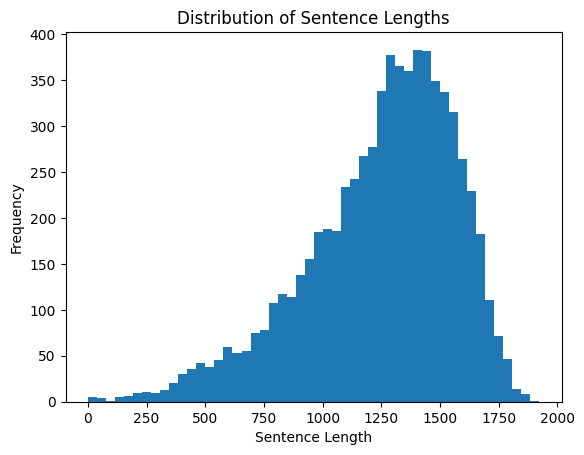

In [39]:
sentence_lengths = [len(s) for s in train_seq]
plt.hist(sentence_lengths, bins=50)
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Sentence Length')
plt.ylabel('Frequency')
plt.show()

In [40]:
lb = LabelEncoder()
y_train = lb.fit_transform(y_train)
y_val = lb.transform(y_val)


In [41]:
max_len = 1000
train_padded = pad_sequences(train_seq, maxlen=max_len, padding='post', truncating='post')
val_padded = pad_sequences(val_seq, maxlen=max_len, padding='post', truncating='post')

**You  are doing Great so far!**

### Modelling using Pytorch

In [42]:
emb_size = 64
vocab_size = len(tokenizer.word_index) + 1
input_shape = (max_len,)
model = Sequential([
    Embedding(vocab_size, emb_size, input_length=max_len),
    Bidirectional(SimpleRNN(128,return_sequences=True)),
    Bidirectional(SimpleRNN(64)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [44]:
model.fit(train_padded, y_train, validation_data=(val_padded, y_val), epochs=20 ,batch_size=64)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 47s 340ms/step - accuracy: 0.1797 - loss: 2.4070 - val_accuracy: 0.2238 - val_loss: 2.2908
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 295ms/step - accuracy: 0.1820 - loss: 2.3349 - val_accuracy: 0.2215 - val_loss: 2.2765
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 304ms/step - accuracy: 0.1964 - loss: 2.3222 - val_accuracy: 0.2203 - val_loss: 2.2785
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 291ms/step - accuracy: 0.1977 - loss: 2.3199 - val_accuracy: 0.2203 - val_loss: 2.2805
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 31s 289ms/step - accuracy: 0.2050 - loss: 2.3078 - val_accuracy: 0.2076 - val_loss: 2.2700
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 289ms/step - accuracy: 0.2055 - loss: 2.2977 - val_accuracy: 0.2203 - val_loss: 2.2668
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 290ms/step - accuracy: 0.2049 - loss: 2.2988 - val_accuracy: 0.2191 - val_loss: 2.2796
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 32s 289ms/step - accuracy: 0.2019 - loss: 2

#### Evaluation

**Evaluation metric:**
Precision

In [45]:
model.evaluate(val_padded, y_val)

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.1465 - loss: 3.1360


[3.136037826538086, 0.14648212492465973]

In [46]:
y_pred = model.predict(val_padded)
y_pred = np.argmax(y_pred, axis=1)

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step


In [55]:
precision_score(y_val, y_pred, average='weighted')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.14503273256282248

### Enhancement

In [60]:
emb_size = 64
vocab_size = len(tokenizer.word_index) + 1
input_shape = (max_len,)
model2 = Sequential([
    Embedding(vocab_size, emb_size, input_length=max_len),
    LSTM(128,return_sequences=True),
    LSTM(64),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(16 , activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 1000, 64)       │     8,082,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 1000, 256)      │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,596,978 (93.83 MB)

 Trainable params: 8,198,992 (31.28 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,397,986 (62.55 MB)

In [61]:
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [62]:
model2.fit(train_padded, y_train, validation_data=(val_padded, y_val), epochs=10)

Epoch 1/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.1899 - loss: 2.3339 - val_accuracy: 0.1626 - val_loss: 2.2854
Epoch 2/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.2042 - loss: 2.2982 - val_accuracy: 0.2203 - val_loss: 2.2650
Epoch 3/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.2010 - loss: 2.2781 - val_accuracy: 0.2203 - val_loss: 2.2728
Epoch 4/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.2427 - loss: 2.2015 - val_accuracy: 0.1984 - val_loss: 2.3008
Epoch 5/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - accuracy: 0.3050 - loss: 2.0541 - val_accuracy: 0.2018 - val_loss: 2.4050
Epoch 6/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.3924 - loss: 1.8478 - val_accuracy: 0.2018 - val_loss: 2.5475
Epoch 7/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.4777 - loss: 1.6165 - val_accuracy: 0.2122 - val_loss: 2.7920
Epoch 8/10
217/217 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.5571 - loss: 1.3699 - 

### Conclusion and final results


In [56]:
y_pred2 = model2.predict(val_padded)
y_pred2 = np.argmax(y_pred2, axis=1)

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


In [59]:
precision_score(y_val, y_pred2, average='weighted')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


0.10698640744110081

#### Done!